<a href="https://colab.research.google.com/github/hanahmdd/heart-disease-prediction-kaggle/blob/main/Copy_of_Heart_Disease_competition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧪 Ensemble Learning Lab: Bagging, Boosting, and Stacking (Classification)

## 🎯 Objective
In this task, you will **design, train, evaluate, and compare ensemble learning models** for a **classification problem** using real-world data.  
You will work with **Bagging**, **Boosting**, and **Stacking** techniques and analyze their performance using appropriate evaluation metrics.

---

## 📊 Dataset
- **Source**: :contentReference[oaicite:0]{index=0}  
- **Competition**: *Playground Series – Season 6, Episode 2*  
- **Problem Type**: **Supervised Classification**

🔗 Dataset link:  
[URL](https://www.kaggle.com/competitions/playground-series-s6e2/overview)

> **Note**: You must download the dataset using the Kaggle API or manually upload it to Colab/Jupyter.

---

## 🧠 Models to Implement

### 1️⃣ Bagging
- **Model**: `BaggingClassifier`
- **Base Estimator**: Decision Tree (recommended)
- Key hyperparameters to explore:
  - `n_estimators`
  - `max_samples`
  - `max_features`
  - `bootstrap`

---

### 2️⃣ Boosting Models

#### a) AdaBoost
- **Model**: `AdaBoostClassifier`
- Base estimator: Decision Tree (stump recommended)
- Tune:
  - `n_estimators`
  - `learning_rate`

#### b) Gradient Boosting
- **Model**: `GradientBoostingClassifier`
- Tune:
  - `n_estimators`
  - `learning_rate`
  - `max_depth`
  - `subsample`

#### c) XGBoost
- **Model**: `XGBClassifier`
- Tune:
  - `n_estimators`
  - `learning_rate`
  - `max_depth`
  - `subsample`
  - `colsample_bytree`

> ⚠️ Handle class imbalance if present.

---

### 3️⃣ Stacking
- **Model**: `StackingClassifier`
- **Base learners** (example):
  - Logistic Regression
  - Random Forest
  - Gradient Boosting
- **Meta-learner**:
  - Logistic Regression (recommended)

---

## ⚙️ Task Instructions

### 🔹 Step 1: Data Preparation
- Load training data
- Separate features and target
- Handle missing values (if any)
- Encode categorical variables
- Perform train/validation split
- Apply feature scaling where necessary

---

### 🔹 Step 2: Model Training
- Train **each ensemble model independently**
- Use **cross-validation** where appropriate
- Record training time and key hyperparameters

---

### 🔹 Step 3: Evaluation Metrics
Evaluate all models using:
- **Accuracy**
- **Precision**
- **Recall**
- **F1-score**
- **ROC-AUC**
- **Confusion Matrix**

---

### 🔹 Step 4: Model Comparison
Create a **comparison table** that includes:
- Model name
- Accuracy
- F1-score
- ROC-AUC
- Training time
- Key observations

---

## 📈 Analysis & Discussion (Required)

Answer the following:
1. Which ensemble method performed best and why?
2. How does **bagging** differ from **boosting** in terms of bias and variance?
3. Did stacking outperform individual ensemble models?
4. Which model would you choose for deployment and why?
5. What are the computational trade-offs between these methods?

---

## 📝 Deliverables
- Fully executable notebook
- Clean, well-documented code
- Final comparison table
- Written analysis and conclusions

---

## ⭐ Bonus (Optional)
- Perform **hyperparameter tuning** using GridSearchCV or RandomizedSearchCV
- Plot **ROC curves** for all models
- Analyze **feature importance** for boosting models

---

🎓 **Learning Outcome**  
By completing this task, you will gain hands-on experience with advanced ensemble techniques and develop a strong intuition for **when and why to use bagging, boosting, or stacking in classification problems**.

In [3]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

In [4]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

train.shape


(630000, 15)

In [5]:
test.shape

(270000, 14)

In [6]:
train.describe()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873
std,181865.479132,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007
min,0.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,157499.750000,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,314999.500000,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000
75%,472499.250000,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000
max,629999.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [7]:
train.isnull().sum()

,0
id,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0


In [8]:

train["Heart Disease"] = train["Heart Disease"].map({
    "Presence": 1,
    "Absence": 0
})

train["Heart Disease"].value_counts()

,count
Heart Disease,
0,347546
1,282454


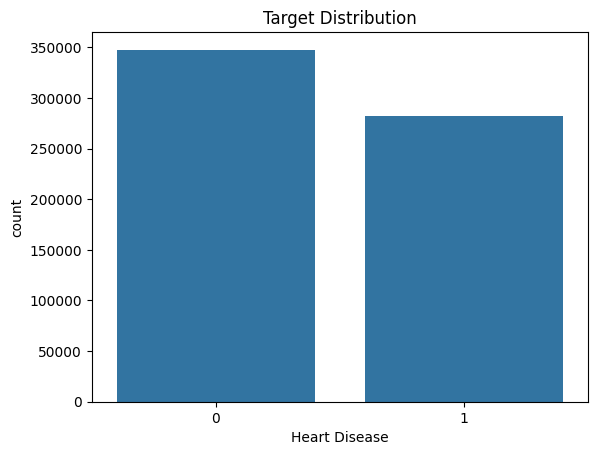

,proportion
Heart Disease,
0,0.55166
1,0.44834


In [9]:

sns.countplot(x="Heart Disease", data=train)
plt.title("Target Distribution")
plt.show()

train["Heart Disease"].value_counts(normalize=True)

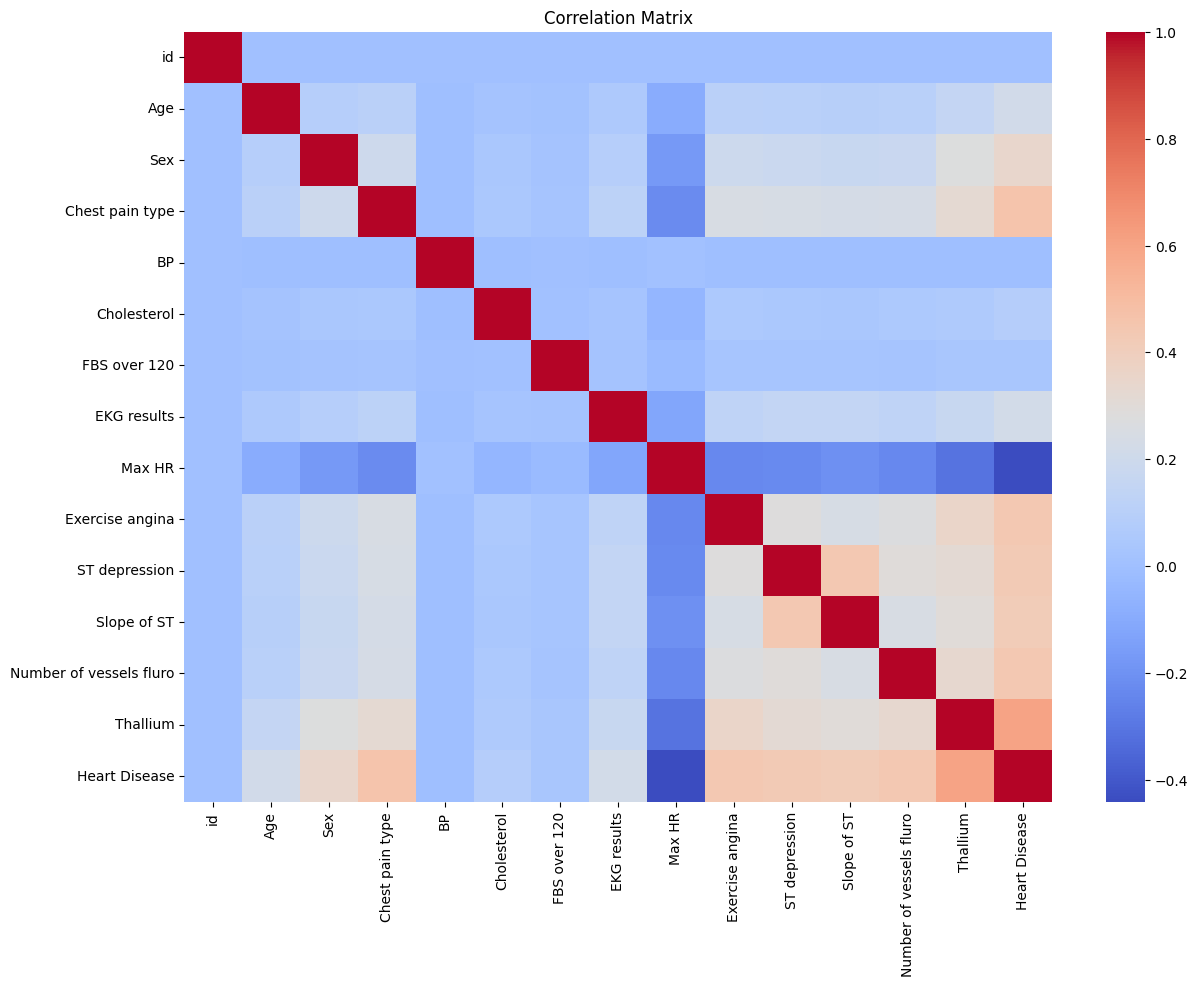

,Heart Disease
Heart Disease,1.000000
Thallium,0.605776
Chest pain type,0.460684
Exercise angina,0.441864
Number of vessels fluro,0.438604
ST depression,0.430641
Slope of ST,0.415050
Sex,0.342446
EKG results,0.218961
Age,0.212091


In [10]:

plt.figure(figsize=(14,10))
corr = train.corr()
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

corr["Heart Disease"].sort_values(ascending=False)

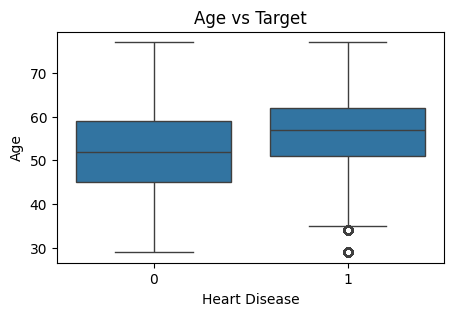

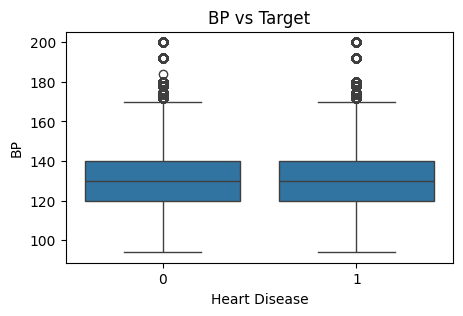

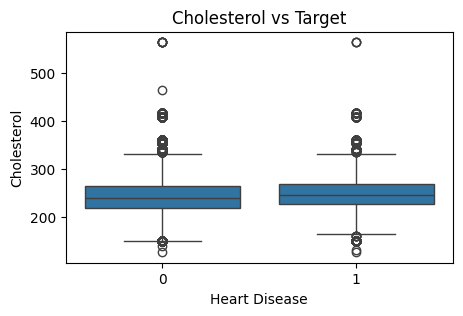

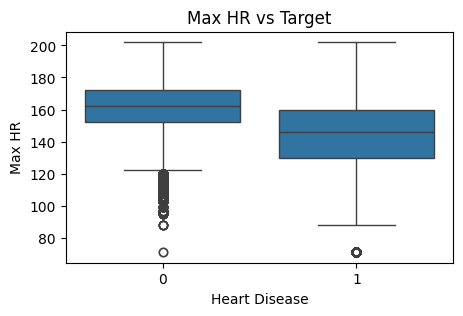

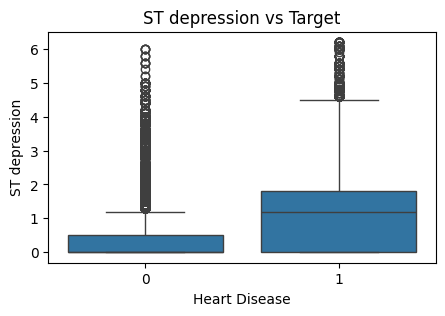

In [11]:

numeric_cols = ["Age","BP","Cholesterol","Max HR","ST depression"]

for col in numeric_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x="Heart Disease", y=col, data=train)
    plt.title(f"{col} vs Target")
    plt.show()

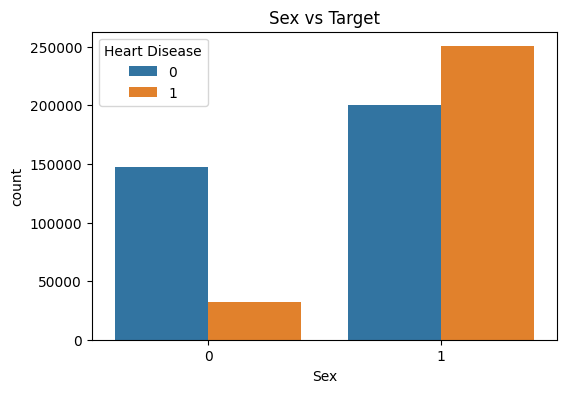

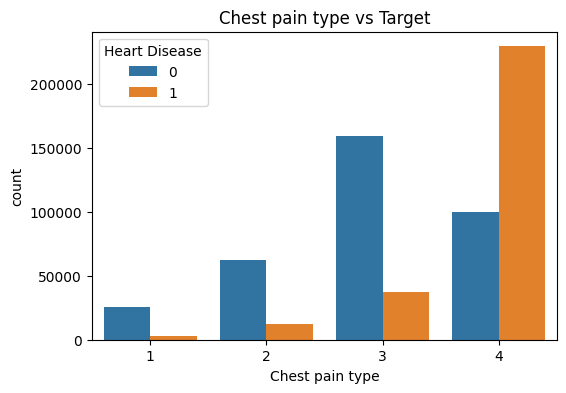

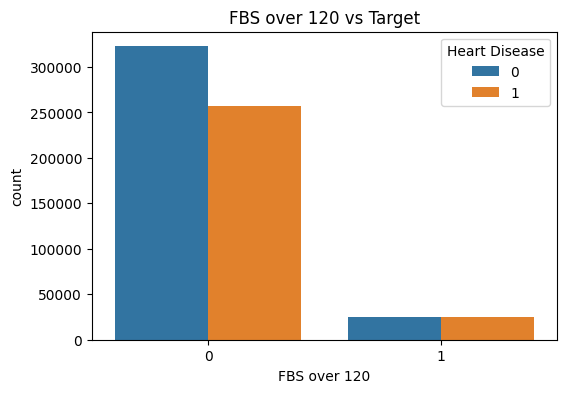

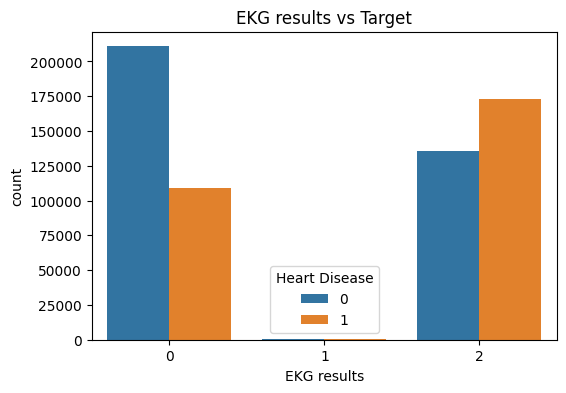

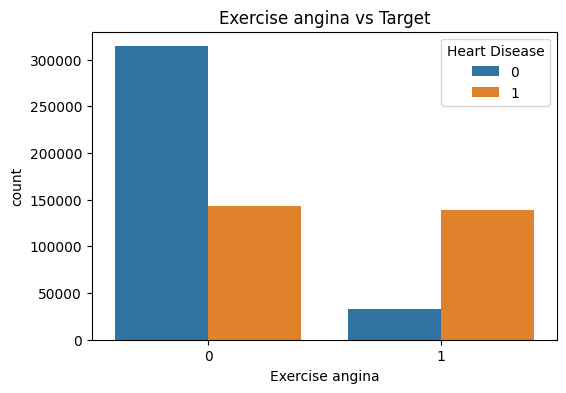

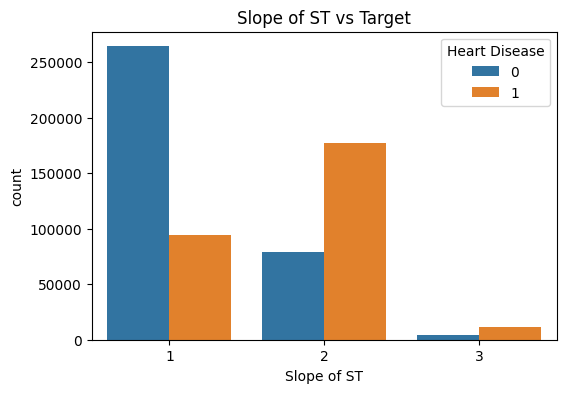

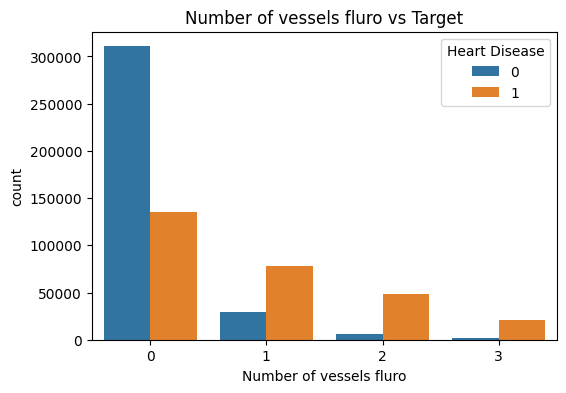

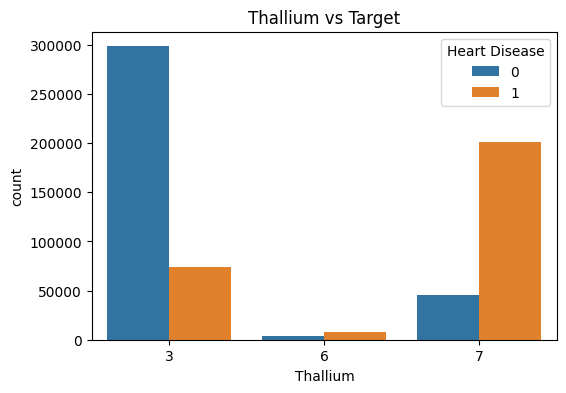

,Heart Disease
Heart Disease,1.000000
Thallium,0.605776
Chest pain type,0.460684
Exercise angina,0.441864
Max HR,0.440985
Number of vessels fluro,0.438604
ST depression,0.430641
Slope of ST,0.415050
Sex,0.342446
EKG results,0.218961


In [12]:

cat_cols = [
    "Sex",
    "Chest pain type",
    "FBS over 120",
    "EKG results",
    "Exercise angina",
    "Slope of ST",
    "Number of vessels fluro",
    "Thallium"
]

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue="Heart Disease", data=train)
    plt.title(f"{col} vs Target")
    plt.show()

train.drop(columns=["id"]).corr()["Heart Disease"].abs().sort_values(ascending=False)

In [13]:

X = train.drop(columns=["Heart Disease", "id"])
y = train["Heart Disease"]

X_test = test.drop(columns=["id"])

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape
X_val.shape

(126000, 13)

In [14]:
def evaluate_model(model, name):
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    preds = model.predict(X_val)
    probs = model.predict_proba(X_val)[:,1]

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_val, preds),
        "Precision": precision_score(y_val, preds),
        "Recall": recall_score(y_val, preds),
        "F1-score": f1_score(y_val, preds),
        "ROC-AUC": roc_auc_score(y_val, probs),
        "Training Time (s)": train_time
    }

In [15]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

bagging_results = evaluate_model(bagging, "Bagging")
bagging_results

{'Model': 'Bagging',
 'Accuracy': 0.8764126984126984,
 'Precision': 0.8685002071288341,
 'Recall': 0.8535872970915721,
 'F1-score': 0.8609791808020569,
 'ROC-AUC': np.float64(0.9422798889849575),
 'Training Time (s)': 81.5886812210083}

In [16]:
adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

adaboost_results = evaluate_model(adaboost, "AdaBoost")
adaboost_results

{'Model': 'AdaBoost',
 'Accuracy': 0.8806984126984126,
 'Precision': 0.8970940367411835,
 'Recall': 0.8289993096245419,
 'F1-score': 0.861703497893168,
 'ROC-AUC': np.float64(0.9496491276168614),
 'Training Time (s)': 22.565955877304077}

In [17]:
gb = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_results = evaluate_model(gb, "Gradient Boosting")
gb_results

{'Model': 'Gradient Boosting',
 'Accuracy': 0.8875952380952381,
 'Precision': 0.8819527161162245,
 'Recall': 0.86507585279071,
 'F1-score': 0.873432766463213,
 'ROC-AUC': np.float64(0.9540621911390847),
 'Training Time (s)': 81.9799747467041}

In [18]:
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="auc",
    random_state=42,
    tree_method="hist",
    n_jobs=-1
)

xgb_results = evaluate_model(xgb, "XGBoost")
xgb_results

{'Model': 'XGBoost',
 'Accuracy': 0.889984126984127,
 'Precision': 0.8834715650468669,
 'Recall': 0.8692712113433998,
 'F1-score': 0.8763138640541072,
 'ROC-AUC': np.float64(0.956139636667677),
 'Training Time (s)': 17.691123008728027}

In [19]:
stack = StackingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(n_estimators=100, random_state=42)),
        ("gb", GradientBoostingClassifier(n_estimators=100, random_state=42)),
        ("lr", LogisticRegression(max_iter=1000))
    ],
    final_estimator=LogisticRegression(),
    n_jobs=-1
)

stack_results = evaluate_model(stack, "Stacking")
stack_results

{'Model': 'Stacking',
 'Accuracy': 0.8883492063492063,
 'Precision': 0.8824579434197003,
 'Recall': 0.8663680940326778,
 'F1-score': 0.8743390024296127,
 'ROC-AUC': np.float64(0.9544946401443848),
 'Training Time (s)': 736.0655598640442}

In [20]:
results_df = pd.DataFrame([
    bagging_results,
    adaboost_results,
    gb_results,
    xgb_results,
    stack_results
])

results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Training Time (s)
0,Bagging,0.876413,0.868500,0.853587,0.860979,0.942280,81.588681
1,AdaBoost,0.880698,0.897094,0.828999,0.861703,0.949649,22.565956
2,Gradient Boosting,0.887595,0.881953,0.865076,0.873433,0.954062,81.979975
3,XGBoost,0.889984,0.883472,0.869271,0.876314,0.956140,17.691123
4,Stacking,0.888349,0.882458,0.866368,0.874339,0.954495,736.065560
